# Fitting Examples

This notebook shows how to use the `fit` library to perform easily fit operations using [RooFit](https://root.cern.ch/doc/master/group__Roofitmain.html).
The fitting operations are built around the [`RooWorkspace`](https://root.cern.ch/doc/master/classRooWorkspace.html) class from RooFit. Let's see how to run simple and complex fits using the helper functions.

## My First Fit

Let's run a simple fit of a Gaussian distribution. To create the workspace and the pdfs, we will use the `FitModels` class, which includes a number of predefined models and relevant variables.

In [1]:
from analysis_helpers.fit import FitModels
fm = FitModels()

We first create the RooFit Workspace

In [2]:
ws = fm.simple_workspace('X',-10,10,'Observable','a.u.')
ws.Print('V')

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::X

RooWorkspace(ws) ws contents

variables
---------
(X)



Let's add the gaussian

In [3]:
gau = fm.gaussian(ws, 'gau', 'X')

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::gau_m
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::gau_s
[#0] WARNING:InputArguments -- The parameter 'gau_s' with range [0, 20] of the RooGaussian 'gau_gau' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooGaussian::gau_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::X for import of RooGaussian::gau_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gau_m for import of RooGaussian::gau_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gau_s for import of RooGaussian::gau_gau


and generate some data points

In [4]:
data = gau.generate(ws.argSet(['X']),10000)

To fit the data with the model, we can use the functions defined in the class `FitUtils`

In [5]:
from analysis_helpers.fit import FitUtils
fu = FitUtils()

In [6]:
res = fu.fit_to_data(gau, data)

[#1] INFO:Fitting -- RooAbsPdf::fitTo(gau_gau_over_gau_gau_Int[X]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using generic CPU library compiled with no vectorizations
[#1] INFO:Fitting -- Creation of NLL object took 10.3926 ms
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_gau_gau_over_gau_gau_Int[X]_gau_gauData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- [fitFCN] No discrete parameters, performing continuous minimization only
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 21094.3162864796795
Edm   = 9.62099763727808778e-07
Nfcn  = 26
gau_m	  = 0.0132935	 +/-  0.0199475	(limited)
gau_s	  = 1.99473	 +/-  0.0141063	(limited)
Fit Result
Fit status = 0
Minuit status = 3
Number of Loops = 2
Real Time  = 0.05846691131591797
CPU Time  = 0.06999999999999984


Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 740.459 μs
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       21094.60709 Edm =      0.2898383621 NCalls =     11
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 21094.60709
  Edm           : 0.2898383621
  Internal parameters:	[                0     -0.927295218]	
  Internal gradient  :	[     -332.3324515      157.0014147]	
  Internal covariance matrix:
[[  8.0001298e-06              0]
 [              0  1.1188092e-05]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       21094.60709 Edm =      0.2898383621 NCalls =     11
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       21094.31629 Edm =   9.132317841e-07 NCalls =     16
Info in <Minuit2>: MnHesse Done after 646.958 μs
Info in <Min

[#1] INFO:Fitting -- RooAbsPdf::fitTo(gau_gau_over_gau_gau_Int[X]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 96.625 μs
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_gau_gau_over_gau_gau_Int[X]_gau_gauData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- [fitFCN] No discrete parameters, performing continuous minimization only
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 21094.316285516099
Edm   = 9.42678224089769987e-10
Nfcn  = 25
gau_m	  = 0.0132935	 +/-  0.0199473	(limited)
gau_s	  = 1.99471	 +/-  0.014106	(limited)

  RooFitResult: minimized FCN value: 21094.3, estimated distance to minimum: 9.45535e-10
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 

    Floating Parameter  InitialValue    FinalVa

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 323.25 μs
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       21094.31629 Edm =   9.050480865e-07 NCalls =      5
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 21094.31629
  Edm           : 9.050480865e-07
  Internal parameters:	[   0.001329351381    -0.9281734911]	
  Internal gradient  :	[  0.0004275515957      0.571581475]	
  Internal covariance matrix:
[[  7.9580483e-06              0]
 [              0  1.1080904e-05]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       21094.31629 Edm =   9.050480865e-07 NCalls =      5
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       21094.31629 Edm =   2.853980898e-16 NCalls =     11
Info in <Minuit2>: MnHesse Done after 898.958 μs
Info in <M

Now plot the data and the fit results superimposed.

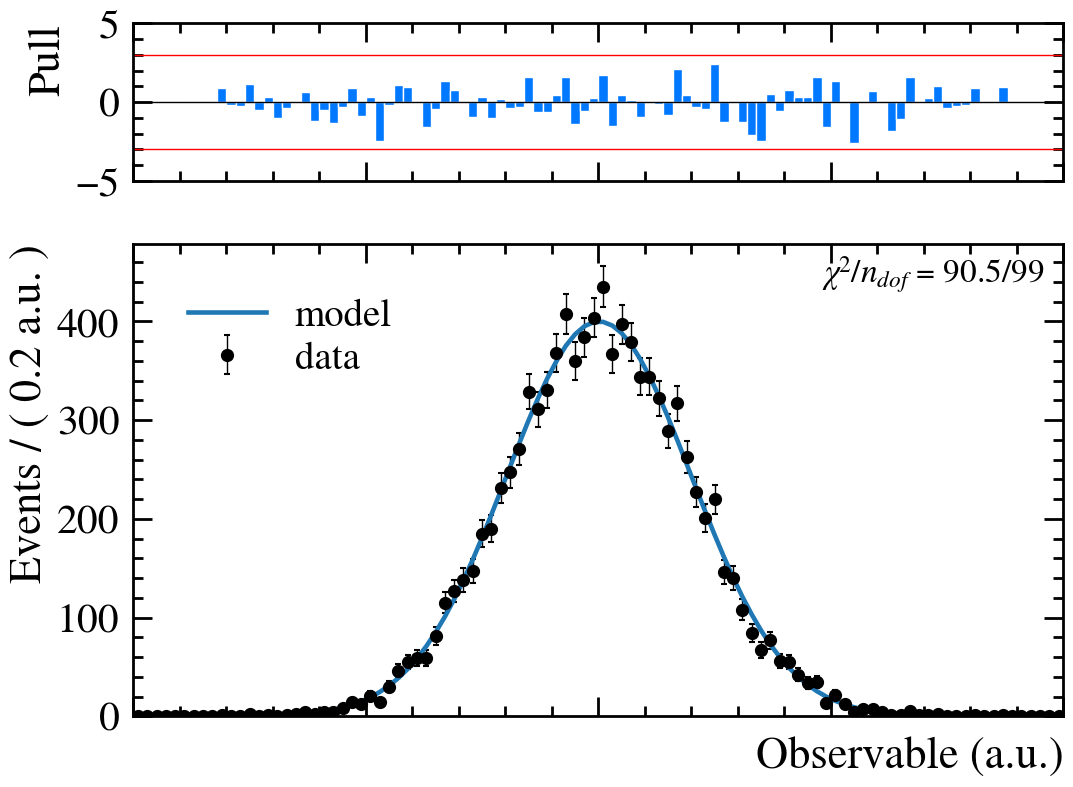

In [7]:
fr = ws.var('X').frame()
data.plotOn(fr)
gau.plotOn(fr)
fig, ax = fu.plot_fit_and_residuals_mpl(fr, labels=['data','model'])

## Complex Model Building

Complex model building can be achieved by means of the helper function `add_to_workspace`.
Let's see for example how to build a simultaneous pdf to fit a complex model from the [`rf501` tutorial](https://root.cern/doc/master/rf501__simultaneouspdf_8py.html):

$$
\begin{align}
model(x) &= f\cdot Gaus(x,\mu,\sigma) + (1-f)\cdot Cheb(x; a_0, a_1)\\
model_{ctl}(x) &= f_{ctl}\cdot Gaus(x,\mu_{ctl},\sigma) + (1-f)\cdot Cheb(x; a_0^{ctl}, a_1^{ctl})\\
\end{align}
$$

And a simultaneous likelihood

$$
\mathcal{L}(\vec{\theta}) = \mathcal{L}_{data}(\vec{\theta}) + \mathcal{L}_{ctl}(\vec{\theta}_{ctl})
$$

In [8]:
from analysis_helpers.fit import add_to_workspace
from analysis_helpers.root_helpers import import_root_with_proxy
r, _HAS_ROOT = import_root_with_proxy()

In [9]:
ws = fm.simple_workspace('x',-8,8,'Observable','a.u.')
x = ws.var('x')

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::x


create model for signal sample

In [10]:
# signal PDF
gx = fm.gaussian(ws, 'gx', 'x')
ws.var('gx_s').setVal(0.3)
# background PDF
a0 = add_to_workspace(ws, r.RooRealVar('a0','a0',-0.1,-1,1))
a1 = add_to_workspace(ws, r.RooRealVar('a1','a1',0.004,-1,1))
px = add_to_workspace(ws, r.RooChebychev('px','px',x,[a0,a1]))
# composite PDF
f = add_to_workspace(ws, r.RooRealVar('f','f',0.2,0,1))
model = add_to_workspace(ws, r.RooAddPdf('model','model',[gx,px],[f]))

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::gx_m
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::gx_s
[#0] WARNING:InputArguments -- The parameter 'gx_s' with range [0, 16] of the RooGaussian 'gx_gau' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooGaussian::gx_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::x for import of RooGaussian::gx_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gx_m for import of RooGaussian::gx_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gx_s for import of RooGaussian::gx_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::a0
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::a1
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importin

Create model for control sample

In [11]:
# Construct signal pdf.
# NOTE that sigma is shared with the signal sample model
mean_ctl = add_to_workspace(ws, r.RooRealVar("mean_ctl", "mean_ctl", -3, -8, 8))
gx_ctl = add_to_workspace(ws, r.RooGaussian("gx_ctl", "gx_ctl", x, mean_ctl, ws.var("gx_s")))
 
# Construct the background pdf
a0_ctl = add_to_workspace(ws, r.RooRealVar("a0_ctl", "a0_ctl", -0.1, -1, 1))
a1_ctl = add_to_workspace(ws, r.RooRealVar("a1_ctl", "a1_ctl", 0.5, -0.1, 1))
px_ctl = add_to_workspace(ws, r.RooChebychev("px_ctl", "px_ctl", x, [a0_ctl, a1_ctl]))
 
# Construct the composite model
f_ctl = add_to_workspace(ws, r.RooRealVar("f_ctl", "f_ctl", 0.5, 0.0, 1.0))
model_ctl = add_to_workspace(ws, r.RooAddPdf("model_ctl", "model_ctl", [gx_ctl, px_ctl], [f_ctl]))

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::mean_ctl
[#0] WARNING:InputArguments -- The parameter 'gx_s' with range [0, 16] of the RooGaussian 'gx_ctl' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooGaussian::gx_ctl
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::x for import of RooGaussian::gx_ctl
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::mean_ctl for import of RooGaussian::gx_ctl
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gx_s for import of RooGaussian::gx_ctl
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::a0_ctl
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::a1_ctl
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooChebychev::px_ctl
[#1] INFO:ObjectHandling -- RooWorkspace:

Generate events for both samples

In [12]:
# Generate 1000 events in x and y from model
data = model.generate(x, 1000)
data_ctl = model_ctl.generate(x, 2000)

Create index category and join samples

In [13]:
# Define category to distinguish physics and control samples events
sample = add_to_workspace(ws, r.RooCategory("sample", "sample"))
sample.defineType("physics")
sample.defineType("control")
 
# Construct combined dataset in (x,sample)
combData = r.RooDataSet(
    "combData",
    "combined data",
    x,
    Index=sample,
    Import={"physics": data, "control": data_ctl},
)


[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooCategory::sample


Construct a simultaneous pdf in (x, sample)

In [14]:
# Construct a simultaneous pdf using category sample as index: associate model
# with the physics state and model_ctl with the control state
simPdf = add_to_workspace(ws, r.RooSimultaneous("simPdf", "simultaneous pdf", {"physics": model, "control": model_ctl}, sample))

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooSimultaneous::simPdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooCategory::sample for import of RooSimultaneous::simPdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooAddPdf::model_ctl for import of RooSimultaneous::simPdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooGaussian::gx_ctl for import of RooSimultaneous::simPdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::x for import of RooSimultaneous::simPdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::mean_ctl for import of RooSimultaneous::simPdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gx_s for import of RooSimultaneous::simPdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::f_ctl for import of RooSimul

Perform a simultaneous fit

In [15]:
# Perform simultaneous fit of model to data and model_ctl to data_ctl
fitResult = fu.fit_to_data(simPdf, combData, kSilent=True)
fitResult.Print()

Running fit in "Silent" mode

  RooFitResult: minimized FCN value: 8721.11, estimated distance to minimum: 1.39045e-07
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                    a0   -8.9215e-02 +/-  6.18e-02
                a0_ctl   -4.5889e-02 +/-  5.28e-02
                    a1    1.7591e-02 +/-  6.38e-02
                a1_ctl    5.3410e-01 +/-  3.72e-02
                     f    2.1990e-01 +/-  1.60e-02
                 f_ctl    4.9962e-01 +/-  1.24e-02
                  gx_m   -2.4546e-02 +/-  2.77e-02
                  gx_s    3.0875e-01 +/-  8.43e-03
              mean_ctl   -3.0190e+00 +/-  1.09e-02



Plot model slices on data slices. It should be noted that the `plot_fit_and_residuals` function calculates the residuals from the latest pdf drawn on the frame, therefore plotting the initial PDF twice.

[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) directly selected PDF components: (px)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) indirectly selected PDF components: ()
[#1] INFO:Plotting -- RooSimultaneous::plotOn(simPdf) plot on x averages with data index category (sample)
[#1] INFO:Plotting -- RooSimultaneous::plotOn(simPdf) plot on x averages with data index category (sample)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(simPdf) directly selected PDF components: (px_ctl)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(simPdf) indirectly selected PDF components: (model_ctl)
[#1] INFO:Plotting -- RooSimultaneous::plotOn(simPdf) plot on x averages with data index category (sample)
[#1] INFO:Plotting -- RooSimultaneous::plotOn(simPdf) plot on x averages with data index category (sample)
[#1] INFO:Plotting -- RooSimultaneous::plotOn(simPdf) plot on x averages with data index category (sample)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(simPdf) directly selected PDF components: (px,px_ctl)
[#1] INFO:Pl

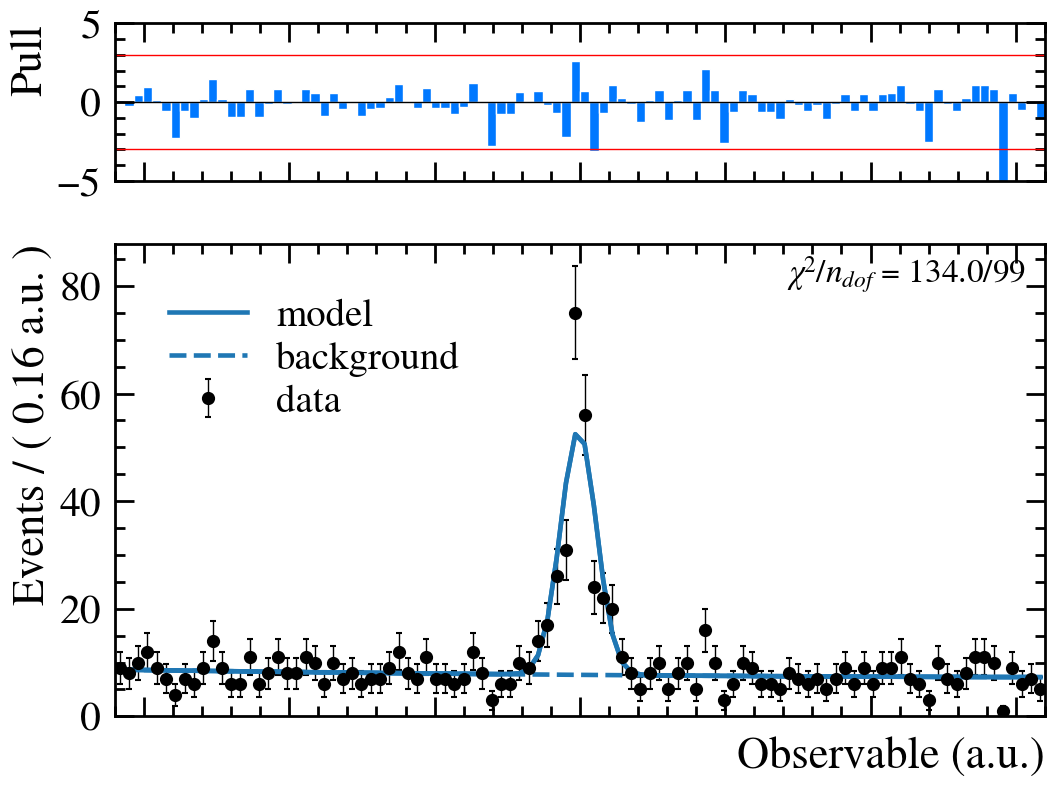

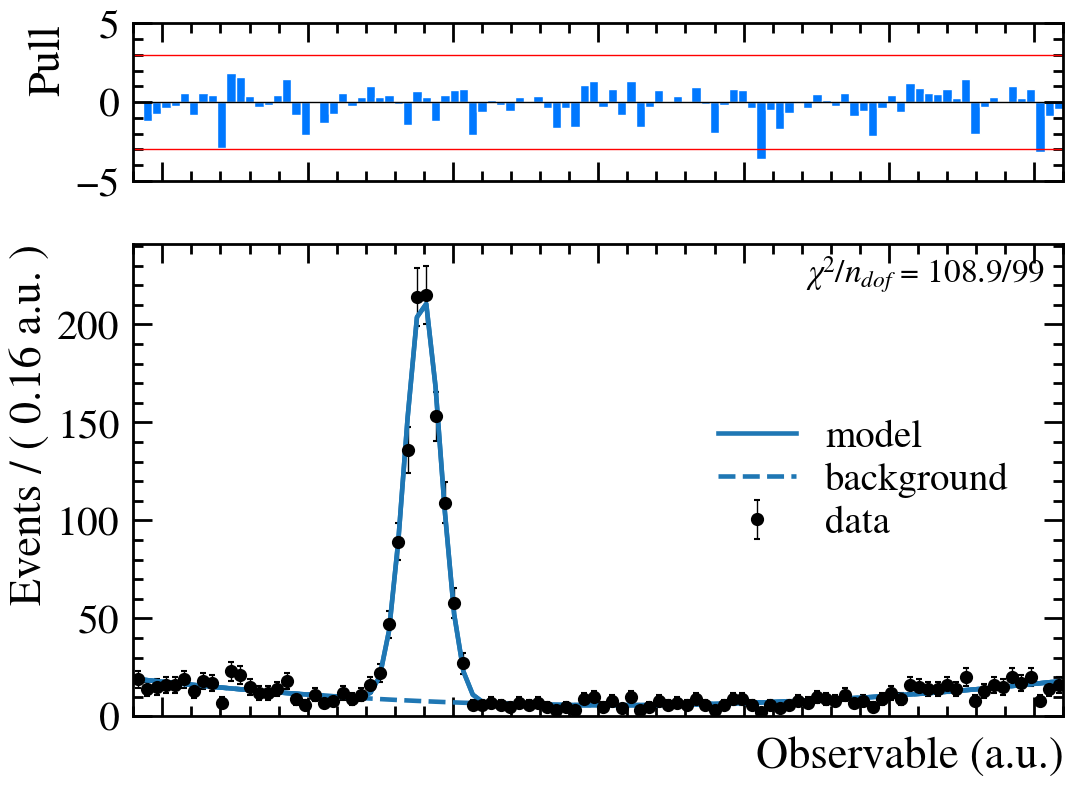

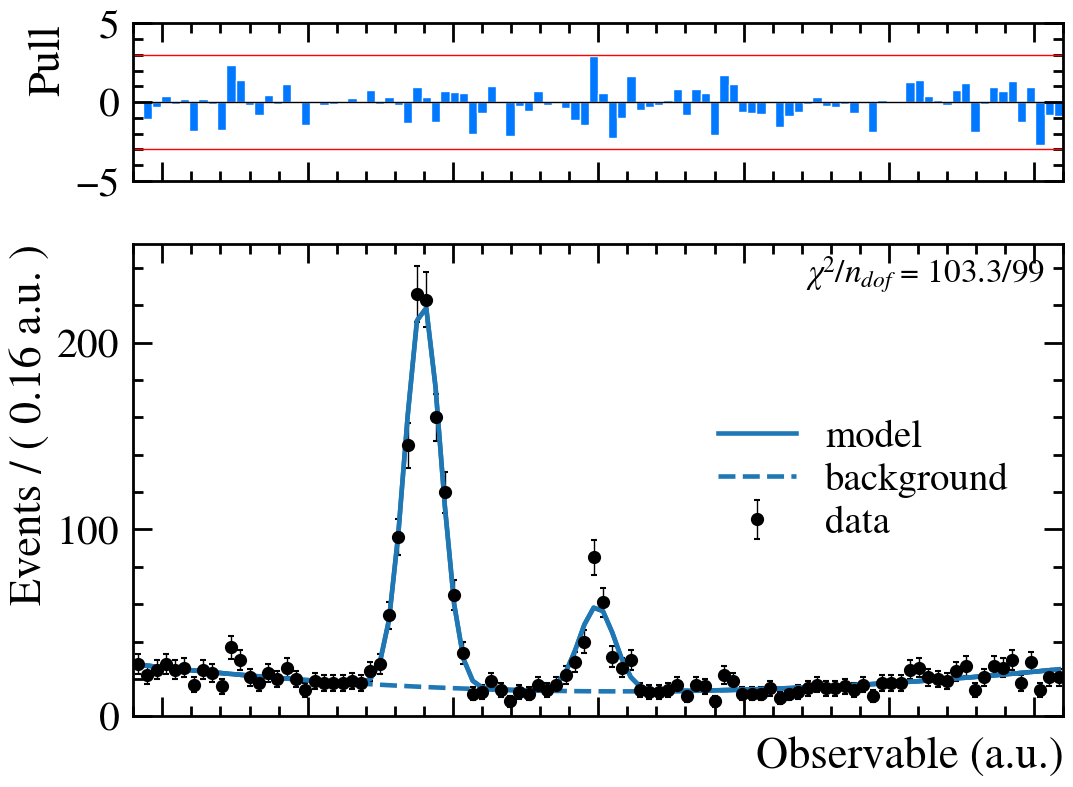

In [16]:
# Make a frame for the physics sample
frame1 = x.frame(Title="Physics sample")
 
# Plot all data tagged as physics sample
slicedData1 = combData.reduce(Cut="sample==sample::physics")
slicedData1.plotOn(frame1)
 
# Plot "physics" slice of simultaneous pdf.
simPdf.getPdf("physics").plotOn(frame1)
simPdf.getPdf("physics").plotOn(frame1, Components="px", LineStyle="--")
simPdf.getPdf("physics").plotOn(frame1) # plotting again the PDF to calculate the residuals correctly
fig, ax = fu.plot_fit_and_residuals_mpl(frame1, labels=['data','model','background'])
 
# The same plot for the control sample slice. We do this with a different
# approach, using the data slice for the projection. This approach is more
# general, because you can plot sums of slices by using logical or in the
# Cut() command.
# NBL You _must_ project the sample index category with data using ProjWData
# as a RooSimultaneous makes no prediction on the shape in the index category
# and can thus not be integrated.
# In other words: Since the PDF doesn't know the number of events in the different
# category states, it doesn't know how much of each component it has to project out.
# This information is read from the data.
frame2 = x.frame(Title="Control sample")
slicedData2 = combData.reduce(Cut="sample==sample::control")
slicedData2.plotOn(frame2)
simPdf.plotOn(frame2, ProjWData=(sample, slicedData2))
simPdf.plotOn(frame2, Components="px_ctl", ProjWData=(sample, slicedData2), LineStyle="--")
simPdf.plotOn(frame2, ProjWData=(sample, slicedData2))
fig, ax = fu.plot_fit_and_residuals_mpl(frame2, labels=['data','model','background'])
 
# The same plot for all the phase space. Here, we can just use the original
# combined dataset.
frame3 = x.frame(Title="Both samples")
combData.plotOn(frame3)
simPdf.plotOn(frame3, ProjWData=(sample, combData))
simPdf.plotOn(frame3, Components="px,px_ctl", ProjWData=(sample, combData), LineStyle="--")
simPdf.plotOn(frame3, ProjWData=(sample, combData))
fig, ax = fu.plot_fit_and_residuals_mpl(frame3, labels=['data','model','background'])

`plot_fit_and_residuals` allow to plot the axes in a matplotlib figure

In [17]:
from analysis_helpers.plotting import create_fit_figure_grid

(<Axes: ylabel='Pull'>,
 <Axes: xlabel='Observable (a.u.)', ylabel='Events / ( 0.16 a.u. )'>)

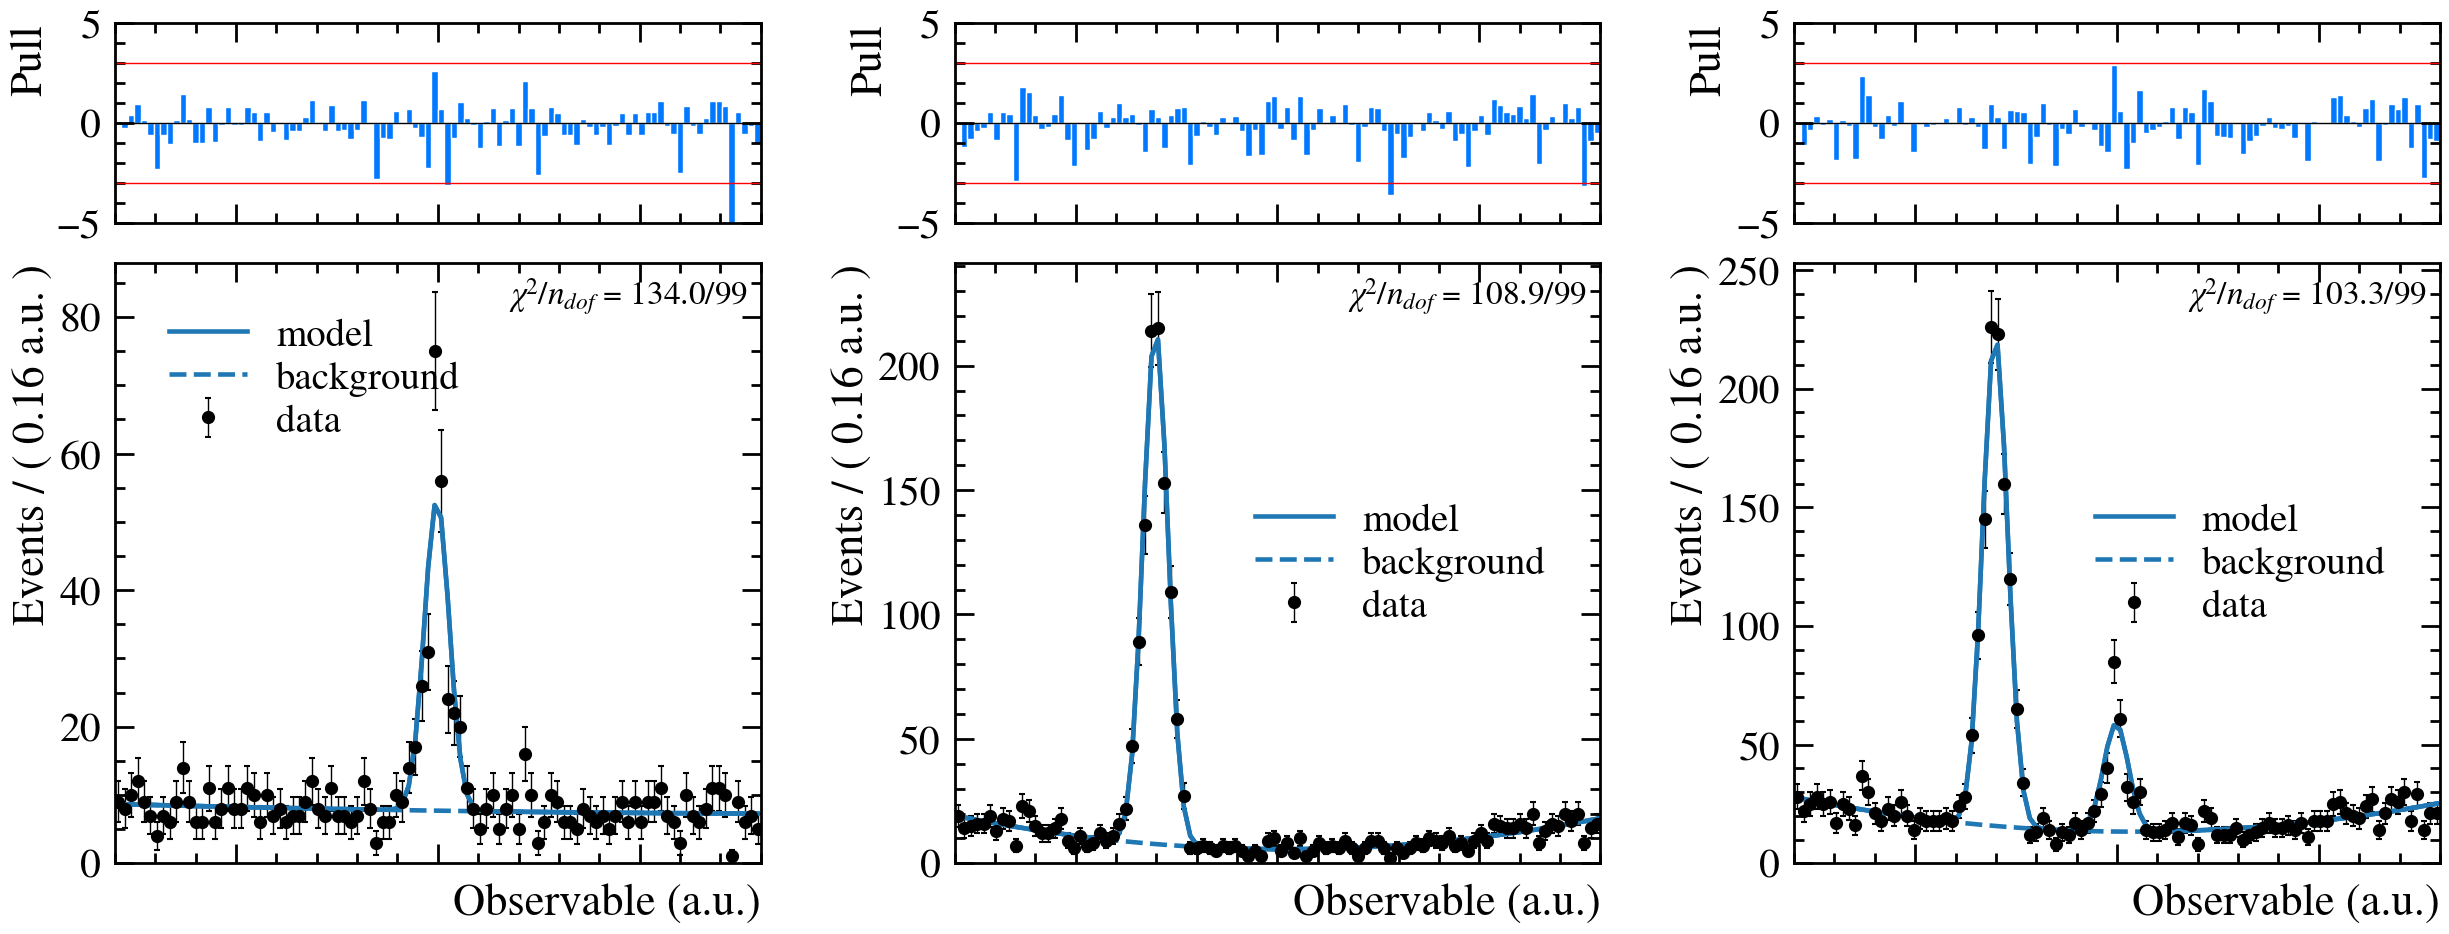

In [18]:
fig, axes_pairs = create_fit_figure_grid(1,3,figsize=(30,10))
fu.plot_fit_and_residuals_mpl(frame1, axes=axes_pairs[0], labels=['data','model','background'])
fu.plot_fit_and_residuals_mpl(frame2, axes=axes_pairs[1], labels=['data','model','background'])
fu.plot_fit_and_residuals_mpl(frame3, axes=axes_pairs[2], labels=['data','model','background'])